# Análise do novo DataSet

## Imports:

In [3]:
import numpy as np # pra parte de algebra
import pandas as pd # para fazer as analises
import matplotlib.pyplot as plt # pros plots
import seaborn as sns # pra gráficos
from pathlib import Path # controlar os caminhos

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # pra matriz de confusão
from sklearn.preprocessing import KBinsDiscretizer # pra discretizar os dados pra por na matriz confusão

## Caminhos:

In [4]:
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent # volta um andar

print("ROOT =", ROOT)

new_csv = ROOT / "data" / "processed" / "adsorption" / "dataset_FULL.csv"
old_csv = ROOT / "_trash" / "data" / "dataset_FULL_LEGADO.csv"

ROOT = /Users/mestre-dos-magos/Documents/ProjetoNakajima/RN_Adsorcao_IC


In [5]:
import pandas as pd
import numpy as np

arquivo = new_csv

df = pd.read_csv(arquivo)

tolerancia = 1e-9

linhas_zeradas = df[np.isclose(df["N_ads_final"], 0, atol=tolerancia)]

qtd_zeradas = len(linhas_zeradas)
seeds_zeradas = linhas_zeradas["seed"].tolist()

print(f"Quantidade de linhas com N_ads_final aproximadamente zero: {qtd_zeradas}")
print("Seeds:")
print(seeds_zeradas)

Quantidade de linhas com N_ads_final aproximadamente zero: 5494
Seeds:
[1624841392, 3496752, 291925685, 541053000, 1563085855, 1473914225, 712525819, 1945559605, 378588279, 1949738635, 744577197, 34820214, 236898343, 1614186233, 473249877, 1604721972, 488953906, 1840079864, 278430688, 1143826601, 18244259, 1495189967, 728846628, 1777947788, 8818841, 643839189, 1712370980, 1367631541, 1593893856, 1177208046, 2040511668, 1108626148, 421795233, 361738204, 1292392192, 2061750902, 151343534, 1921593877, 1681114328, 575945440, 2061985046, 1761312037, 959918979, 169139350, 626223304, 1784259413, 5168935, 1464204854, 1230010782, 733389425, 31928055, 1193551025, 827007971, 668392419, 1565472383, 2033015995, 896917082, 1186947625, 1676898339, 1785131719, 962543890, 1859056902, 1479202081, 51893783, 2117402394, 602563456, 358303249, 1076780285, 2034643014, 1481736646, 793172545, 1344784167, 1373878093, 784031672, 250269955, 723546181, 788972057, 536586320, 793399323, 364837150, 757733901, 2125067

## Carreegar os DataFrames:

In [3]:
df_new = pd.read_csv(new_csv)# lendo e tranformando em dataframe
df_old = pd.read_csv(old_csv)

print("Novo:", df_new.shape) # mostra os shapes - mister olimpia sksksk
print("Legado:", df_old.shape)

Novo: (999001, 231)
Legado: (93420, 231)


## Visual:

In [4]:
tabelaNewDataSet = (
    df_new.head(20)                          # mostre quantas linhas quiser
    .style.set_caption("dataset_FULL – preview")
    .highlight_max(color= "#fd0909")    # exemplo: destaca valores máximos
    .set_table_styles([
        {"selector": "th", "props": "background:#343a40;color:#fff;text-align:center;"},
        {"selector": "td", "props": "padding:6px;"},
        {"selector": "caption", "props": "font-size:15px;font-weight:bold;margin-bottom:6px;"},
    ])
    .format(precision=3)               # ajuste de casas decimais
)  
tabelaDataSetLegado = (
    df_old.head(20)                          # mostre quantas linhas quiser
    .style.set_caption("dataset_FULL – preview")
    .highlight_max(color= "#fd0909")    # exemplo: destaca valores máximos
    .set_table_styles([
        {"selector": "th", "props": "background:#343a40;color:#fff;text-align:center;"},
        {"selector": "td", "props": "padding:6px;"},
        {"selector": "caption", "props": "font-size:15px;font-weight:bold;margin-bottom:6px;"},
    ])
    .format(precision=3)               # ajuste de casas decimais
)  

In [5]:
tabelaNewDataSet

,seed,L,Nz,eps,rho_B,u,D_ax,kL,qmax,b,n,lam_z,rho_g,cp_g,cp_s,D_col,h_w,T_wall,dH,dt,t_end,C_in,T_in,C_out_final,q_out_final,T_out_final,N_ads_final,C_z0,C_z1,C_z2,C_z3,C_z4,C_z5,C_z6,C_z7,C_z8,C_z9,C_z10,C_z11,C_z12,C_z13,C_z14,C_z15,C_z16,C_z17,C_z18,C_z19,C_z20,C_z21,C_z22,C_z23,C_z24,C_z25,C_z26,C_z27,C_z28,C_z29,C_z30,C_z31,C_z32,C_z33,C_z34,C_z35,C_z36,C_z37,C_z38,C_z39,C_z40,C_z41,C_z42,C_z43,C_z44,C_z45,C_z46,C_z47,C_z48,C_z49,C_z50,q_z0,q_z1,q_z2,q_z3,q_z4,q_z5,q_z6,q_z7,q_z8,q_z9,q_z10,q_z11,q_z12,q_z13,q_z14,q_z15,q_z16,q_z17,q_z18,q_z19,q_z20,q_z21,q_z22,q_z23,q_z24,q_z25,q_z26,q_z27,q_z28,q_z29,q_z30,q_z31,q_z32,q_z33,q_z34,q_z35,q_z36,q_z37,q_z38,q_z39,q_z40,q_z41,q_z42,q_z43,q_z44,q_z45,q_z46,q_z47,q_z48,q_z49,q_z50,T_z0,T_z1,T_z2,T_z3,T_z4,T_z5,T_z6,T_z7,T_z8,T_z9,T_z10,T_z11,T_z12,T_z13,T_z14,T_z15,T_z16,T_z17,T_z18,T_z19,T_z20,T_z21,T_z22,T_z23,T_z24,T_z25,T_z26,T_z27,T_z28,T_z29,T_z30,T_z31,T_z32,T_z33,T_z34,T_z35,T_z36,T_z37,T_z38,T_z39,T_z40,T_z41,T_z42,T_z43,T_z44,T_z45,T_z46,T_z47,T_z48,T_z49,T_z50,Qtot_t0,Qtot_t1,Qtot_t2,Qtot_t3,Qtot_t4,Qtot_t5,Qtot_t6,Qtot_t7,Qtot_t8,Qtot_t9,Qtot_t10,Qtot_t11,Qtot_t12,Qtot_t13,Qtot_t14,Qtot_t15,Qtot_t16,Qtot_t17,Qtot_t18,Qtot_t19,Qtot_t20,Qtot_t21,Qtot_t22,Qtot_t23,Qtot_t24,Qtot_t25,Qtot_t26,Qtot_t27,Qtot_t28,Qtot_t29,Qtot_t30,Qtot_t31,Qtot_t32,Qtot_t33,Qtot_t34,Qtot_t35,Qtot_t36,Qtot_t37,Qtot_t38,Qtot_t39,Qtot_t40,Qtot_t41,Qtot_t42,Qtot_t43,Qtot_t44,Qtot_t45,Qtot_t46,Qtot_t47,Qtot_t48,Qtot_t49,Qtot_t50
0,1886039738,0.204,51,0.752,817.809,0.828,0.014,0.042,0.298,0.019,6.261,56.588,0.917,20476.508,2503.195,0.098,50.385,335.103,87714.448,1.762,1761.566,9.207,317.142,9.207,0.000,317.773,0.000,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,9.207,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,317.151,317.164,317.177,317.190,317.203,317.215,317.228,317.241,317.254,317.267,317.280,317.292,317.305,317.318,317.331,317.343,317.356,317.369,317.382,317.394,317.407,317.420,317.433,317.445,317.458,317.471,317.483,317.496,317.509,317.521,317.534,317.546,317.559,317.572,317.584,317.597,317.609,317.622,317.635,317.647,317.660,317.672,317.685,317.697,317.710,317.722,317.734,317.746,317.757,317.767,317.773,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,2082800362,0.741,51,0.700,947.499,0.067,0.000,0.031,4.417,0.018,5.082,57.091,2.140,1013.331,3613.828,0.084,151.123,348.137,99366.351,1.718,1717.686,1.950,278.241,1.950,0.000,348.134,0.000,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,1.950,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,284.593,295.024,303.746,311.040,317.141,322.242,326.509,330.077,333.061,335.556,337.643,339.388,340.847,342.067,343.086,343.937,344.649,345.242,345.738,346.151,346.495,346.782,347.020,347.218,347.

In [6]:
tabelaDataSetLegado

,seed,L,Nz,eps,rho_B,u,D_ax,kL,qmax,b,n,lam_z,rho_g,cp_g,cp_s,D_col,h_w,T_wall,dH,dt,t_end,C_in,T_in,C_out_final,q_out_final,T_out_final,N_ads_final,C_z0,C_z1,C_z2,C_z3,C_z4,C_z5,C_z6,C_z7,C_z8,C_z9,C_z10,C_z11,C_z12,C_z13,C_z14,C_z15,C_z16,C_z17,C_z18,C_z19,C_z20,C_z21,C_z22,C_z23,C_z24,C_z25,C_z26,C_z27,C_z28,C_z29,C_z30,C_z31,C_z32,C_z33,C_z34,C_z35,C_z36,C_z37,C_z38,C_z39,C_z40,C_z41,C_z42,C_z43,C_z44,C_z45,C_z46,C_z47,C_z48,C_z49,C_z50,q_z0,q_z1,q_z2,q_z3,q_z4,q_z5,q_z6,q_z7,q_z8,q_z9,q_z10,q_z11,q_z12,q_z13,q_z14,q_z15,q_z16,q_z17,q_z18,q_z19,q_z20,q_z21,q_z22,q_z23,q_z24,q_z25,q_z26,q_z27,q_z28,q_z29,q_z30,q_z31,q_z32,q_z33,q_z34,q_z35,q_z36,q_z37,q_z38,q_z39,q_z40,q_z41,q_z42,q_z43,q_z44,q_z45,q_z46,q_z47,q_z48,q_z49,q_z50,T_z0,T_z1,T_z2,T_z3,T_z4,T_z5,T_z6,T_z7,T_z8,T_z9,T_z10,T_z11,T_z12,T_z13,T_z14,T_z15,T_z16,T_z17,T_z18,T_z19,T_z20,T_z21,T_z22,T_z23,T_z24,T_z25,T_z26,T_z27,T_z28,T_z29,T_z30,T_z31,T_z32,T_z33,T_z34,T_z35,T_z36,T_z37,T_z38,T_z39,T_z40,T_z41,T_z42,T_z43,T_z44,T_z45,T_z46,T_z47,T_z48,T_z49,T_z50,Qtot_t0,Qtot_t1,Qtot_t2,Qtot_t3,Qtot_t4,Qtot_t5,Qtot_t6,Qtot_t7,Qtot_t8,Qtot_t9,Qtot_t10,Qtot_t11,Qtot_t12,Qtot_t13,Qtot_t14,Qtot_t15,Qtot_t16,Qtot_t17,Qtot_t18,Qtot_t19,Qtot_t20,Qtot_t21,Qtot_t22,Qtot_t23,Qtot_t24,Qtot_t25,Qtot_t26,Qtot_t27,Qtot_t28,Qtot_t29,Qtot_t30,Qtot_t31,Qtot_t32,Qtot_t33,Qtot_t34,Qtot_t35,Qtot_t36,Qtot_t37,Qtot_t38,Qtot_t39,Qtot_t40,Qtot_t41,Qtot_t42,Qtot_t43,Qtot_t44,Qtot_t45,Qtot_t46,Qtot_t47,Qtot_t48,Qtot_t49,Qtot_t50
0,561398046,0.978,51,0.761,381.785,0.808,0.000,0.003,0.136,7.620,1.065,0.772,1.706,1037.205,1118.988,0.049,16.764,306.493,48910.134,0.333,333.321,1.691,301.962,1.604,0.082,302.594,7.531,1.689,1.688,1.686,1.684,1.683,1.681,1.679,1.678,1.676,1.674,1.672,1.671,1.669,1.667,1.666,1.664,1.662,1.660,1.659,1.657,1.655,1.654,1.652,1.650,1.648,1.647,1.645,1.643,1.642,1.640,1.638,1.636,1.635,1.633,1.631,1.630,1.628,1.626,1.624,1.623,1.621,1.619,1.617,1.616,1.614,1.612,1.611,1.609,1.607,1.605,1.604,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.083,0.082,0.082,0.082,0.082,0.082,301.974,301.998,302.021,302.044,302.066,302.088,302.109,302.130,302.150,302.170,302.189,302.208,302.227,302.245,302.263,302.280,302.296,302.313,302.328,302.344,302.359,302.373,302.387,302.401,302.414,302.427,302.439,302.451,302.462,302.473,302.484,302.494,302.503,302.512,302.521,302.529,302.537,302.544,302.551,302.558,302.563,302.569,302.574,302.578,302.582,302.585,302.588,302.590,302.592,302.593,302.594,0.000,0.231,0.466,0.697,0.923,1.144,1.361,1.573,1.780,1.984,2.183,2.378,2.569,2.757,2.940,3.119,3.295,3.467,3.636,3.801,3.963,4.121,4.276,4.428,4.577,4.723,4.866,5.005,5.142,5.276,5.407,5.536,5.662,5.785,5.906,6.024,6.140,6.253,6.364,6.473,6.580,6.684,6.786,6.886,6.984,7.080,7.174,7.266,7.357,7.445,7.531
1,828878294,0.407,51,0.703,410.633,0.931,0.000,0.041,3.467,1.485,1.513,0.827,1.496,1009.602,1090.621,0.237,22.922,301.011,48951.258,0.081,81.127,1.750,316.692,0.010,0.004,313.170,27.488,1.723,1.689,1.645,1.590,1.521,1.435,1.331,1.210,1.073,0.925,0.775,0.633,0.506,0.402,0.319,0.255,0.206,0.169,0.141,0.119,0.102,0.088,0.077,0.068,0.060,0.054,0.048,0.044,0.040,0.036,0.033,0.031,0.028,0.026,0.025,0.023,0.021,0.020,0.019,0.018,0.017,0.016,0.015,0.014,0.013,0.013,0.012,0.012,0.011,0.011,0.010,2.664,2.613,2.546,2.459,2.351,2.218,2.059,1.873,1.662,1.432,1.196,0.966,0.759,0.585,0.447,0.341,0.263,0.205,0.161,0.129,0.105,0.086,0.071,0.060,0.051,0.043,0.037,0.033,0.028,0.025,0.022,0.020,0.018,0.016,0.014,0.013,0.012,0.011,0.010,0.009,0.008,0.007,0.007,0.006,0.006,0.005,0.005,0.005,0.004,0.004,0.004,316.529,316.208,315.891,315.580,315.279,314.990,314.716,314.461,314.230,314.026,313.851,313.705,313.588,313.496,313.425,313.370,313.328,313.295,313.270,313.250,313.234,313.221,313.211,313.203,313.196,313.

## Comparação de Colunas

In [7]:
cols_new = set(df_new.columns)
cols_old = set(df_old.columns)

print("Só no novo:", sorted(cols_new - cols_old))
print("Só no legado:", sorted(cols_old - cols_new))
print("Colunas em comum:", len(cols_new & cols_old))

Só no novo: []
Só no legado: []
Colunas em comum: 231


### Verificando se a valores nulls:

In [8]:
nulls_new = df_new.isnull().sum()
nulls_old = df_old.isnull().sum()

nulls_new[nulls_new > 0].sort_values(ascending=False)

Series([], dtype: int64)

## Análise estátistica:

In [9]:
analise_new = df_new.describe().T
analise_new.head(20)

,count,mean,std,min,25%,50%,75%,max
seed,999001.0,1.074083e+09,6.199059e+08,2453.000000,5.376551e+08,1.074240e+09,1.611719e+09,2.147481e+09
L,999001.0,5.045779e-01,2.856330e-01,0.010001,2.568992e-01,5.043807e-01,7.520116e-01,9.999980e-01
Nz,999001.0,5.100000e+01,0.000000e+00,51.000000,5.100000e+01,5.100000e+01,5.100000e+01,5.100000e+01
eps,999001.0,4.997379e-01,1.732502e-01,0.200002,3.496548e-01,4.993751e-01,6.496414e-01,7.999987e-01
rho_B,999001.0,5.045595e+02,2.858929e+02,10.002293,2.568202e+02,5.043407e+02,7.521348e+02,9.999983e+02
u,999001.0,5.011332e-01,2.884726e-01,0.001001,2.514540e-01,5.014561e-01,7.511148e-01,9.999999e-01
D_ax,999001.0,8.675636e-03,1.892901e-02,0.000001,1.770577e-05,3.140037e-04,5.623553e-03,9.999964e-02
kL,999001.0,1.322533e-01,2.052042e-01,0.001000,5.479146e-03,2.998017e-02,1.643777e-01,8.999980e-01
qmax,999001.0,2.144523e+00,2.491024e+00,0.100000,3.160603e-01,9.996778e-01,3.152109e+00,9.999969e+00
b,999001.0,1.441405e+00,2.263090e+00,0.010000,5.609055e-02,3.143089e-01,1.769783e+00,9.999922e+00


## Organizando os dados:

In [10]:
param_cols = [
    "L", "Nz", "eps", "rho_B", "u", "D_ax", "kL", "qmax", "b", "n",
    "lam_z", "rho_g", "cp_g", "cp_s", "D_col", "h_w", "T_wall", "dH",
    "dt", "t_end", "C_in", "T_in"
]

final_cols = ["C_out_final", "q_out_final", "T_out_final", "N_ads_final"]

cz_cols = [c for c in df_new.columns if c.startswith("C_z")]
qz_cols = [c for c in df_new.columns if c.startswith("q_z")]
tz_cols = [c for c in df_new.columns if c.startswith("T_z")]

### Trabalhando com as Entradas:

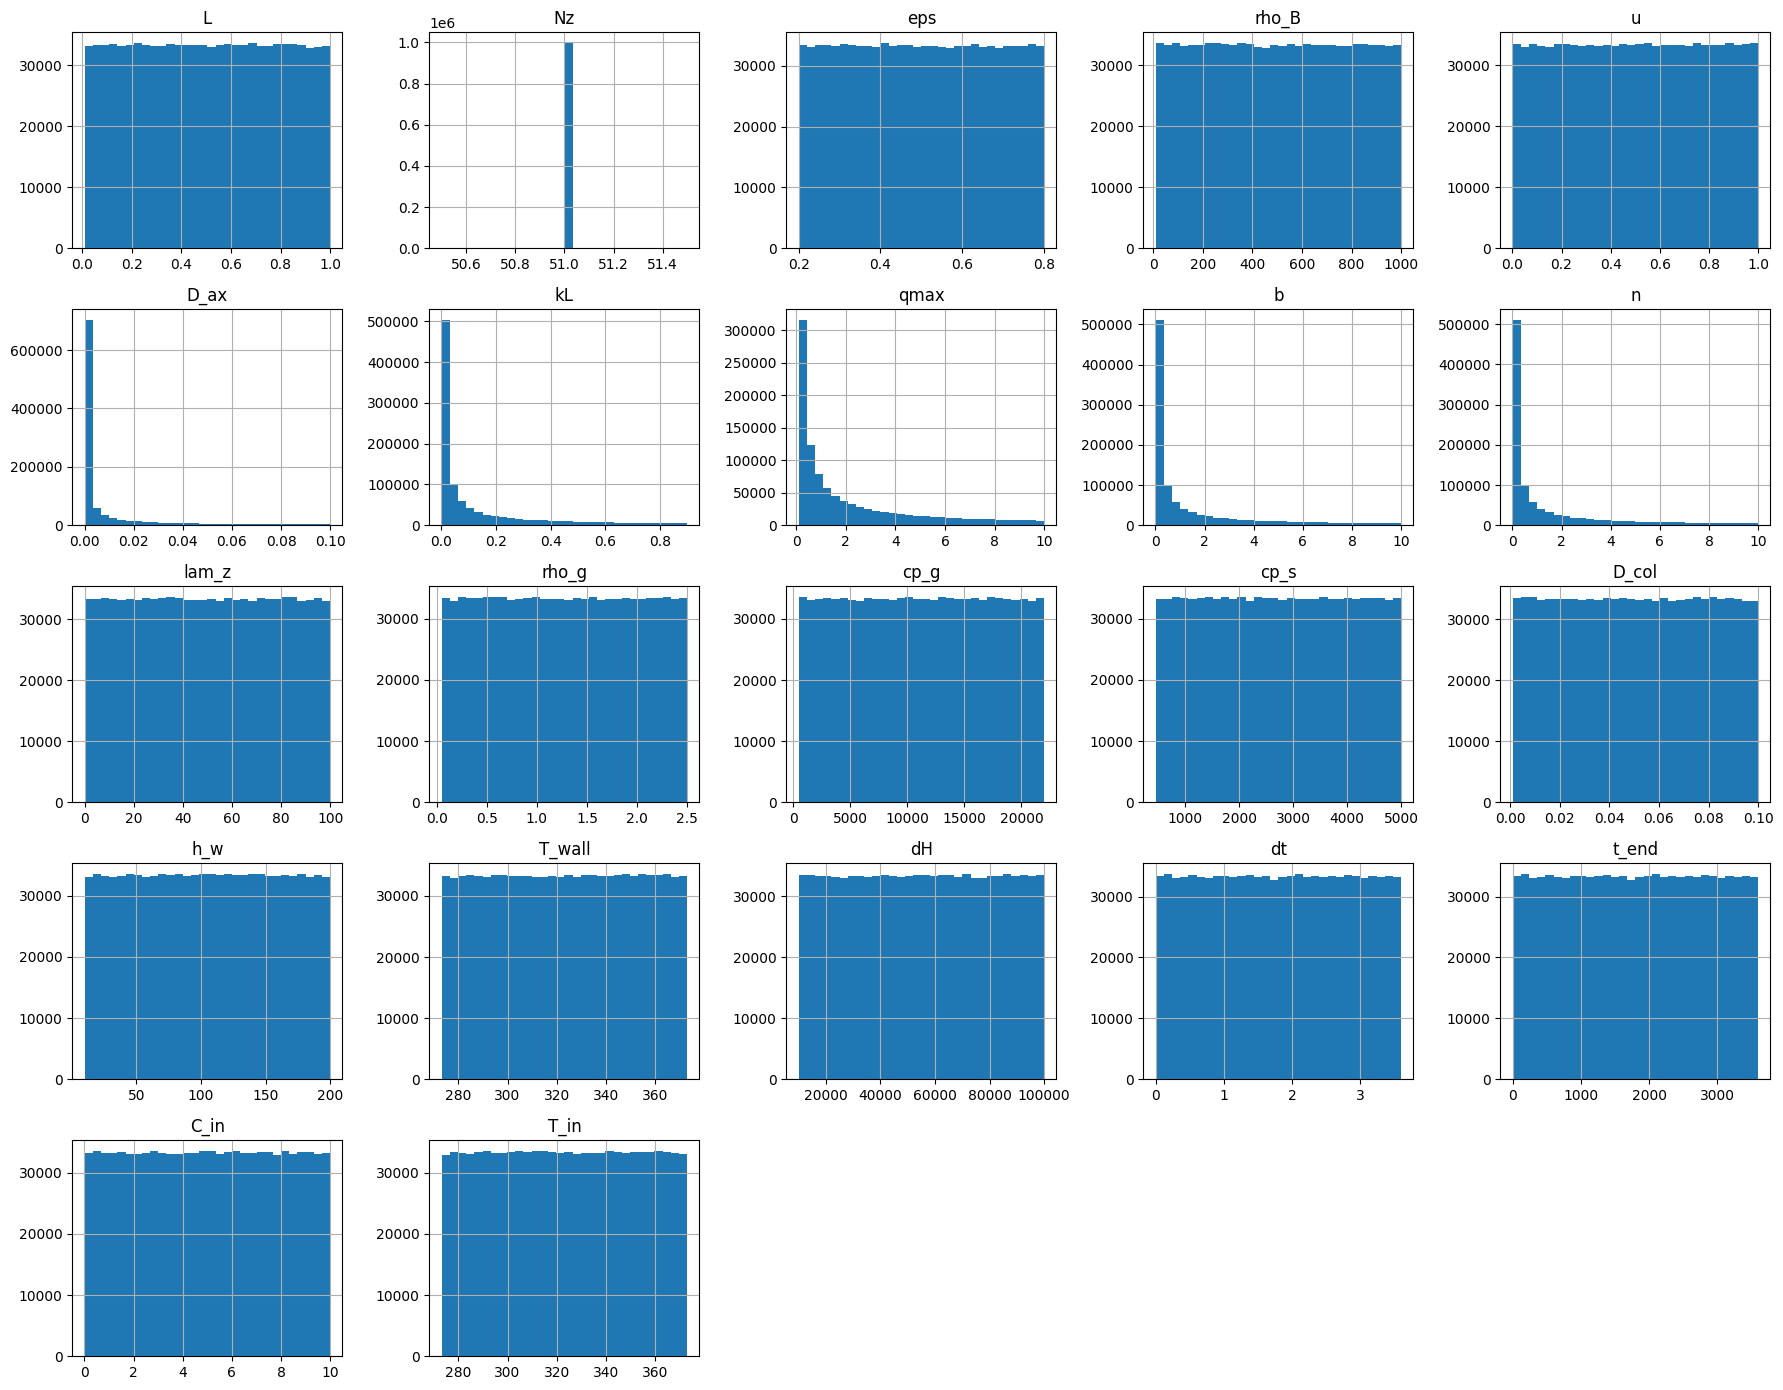

In [11]:
df_new[param_cols].hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

### Outliers:

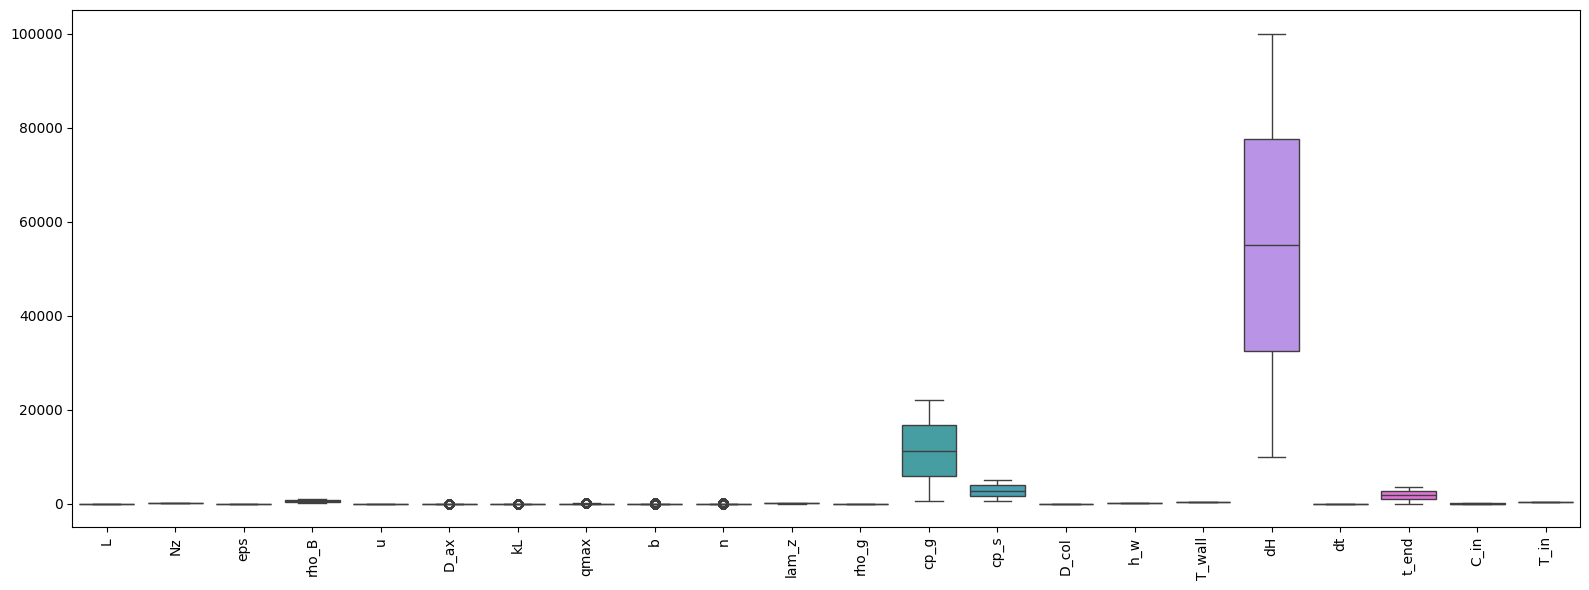

In [12]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_new[param_cols])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Correlações:

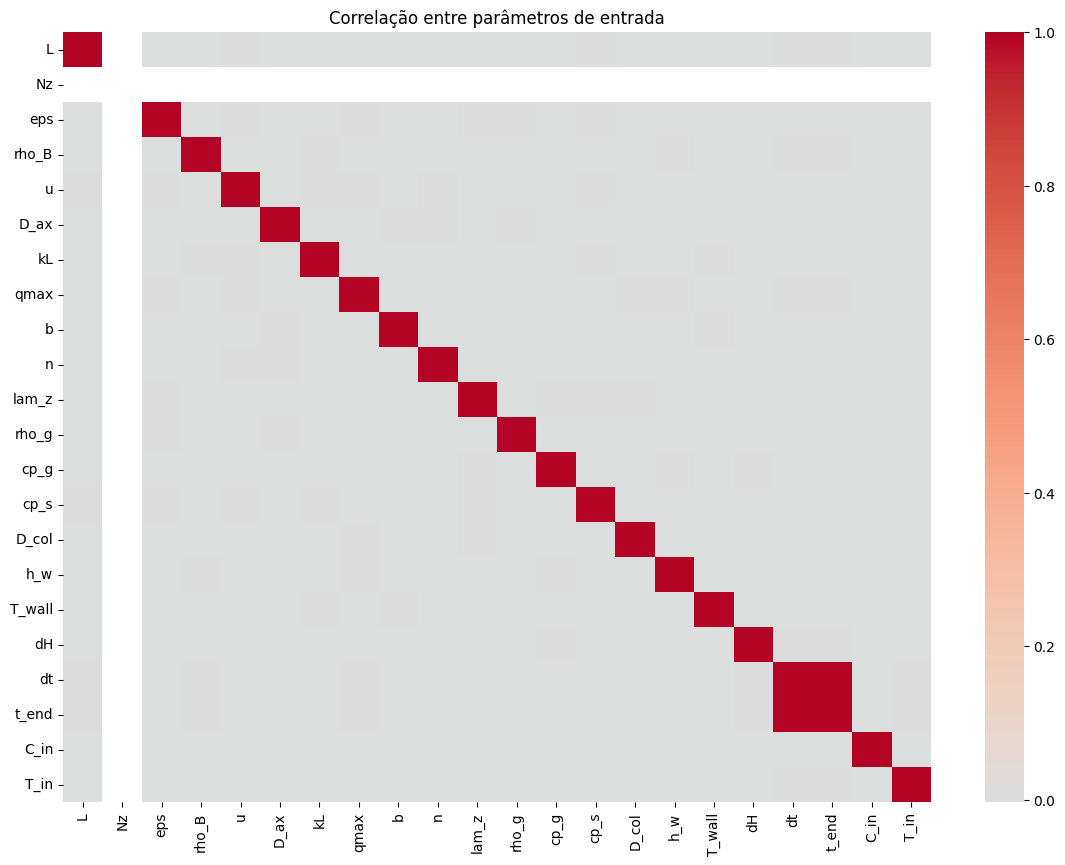

In [ ]:
corr_inputs = df_new[param_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_inputs, cmap="coolwarm", center=0) 
plt.title("Correlação entre parâmetros de entrada") 
plt.show()

## Comparação com o DataSet Antigo

In [14]:
common_cols = [c for c in df_new.columns if c in df_old.columns]

compare_stats = pd.DataFrame({
    "mean_new": df_new[common_cols].mean(),
    "mean_old": df_old[common_cols].mean(),
    "std_new": df_new[common_cols].std(),
    "std_old": df_old[common_cols].std(),
})

compare_stats["mean_diff_abs"] = (compare_stats["mean_new"] - compare_stats["mean_old"]).abs()
compare_stats["std_diff_abs"] = (compare_stats["std_new"] - compare_stats["std_old"]).abs()

compare_stats.sort_values("mean_diff_abs", ascending=False).head(20)

,mean_new,mean_old,std_new,std_old,mean_diff_abs,std_diff_abs
seed,1.074083e+09,4.999968e+08,6.199059e+08,2.891523e+08,5.740861e+08,3.307537e+08
cp_g,1.122517e+04,9.995815e+02,6.220393e+03,1.153123e+02,1.022559e+04,6.105081e+03
dH,5.502184e+04,4.494865e+04,2.599090e+04,1.154048e+04,1.007320e+04,1.445042e+04
cp_s,2.724363e+03,1.000311e+03,1.313352e+03,1.154931e+02,1.724052e+03,1.197859e+03
t_end,1.799437e+03,2.501745e+02,1.039401e+03,1.442572e+02,1.549262e+03,8.951442e+02
rho_B,5.045595e+02,2.746630e+02,2.858929e+02,1.298123e+02,2.298965e+02,1.560806e+02
h_w,1.049948e+02,2.995093e+01,5.478829e+01,1.153191e+01,7.504385e+01,4.325638e+01
Qtot_t40,8.999861e+01,2.330421e+01,2.156087e+02,5.805048e+01,6.669441e+01,1.575582e+02
Qtot_t38,8.926360e+01,2.257486e+01,2.140635e+02,5.721997e+01,6.668874e+01,1.568435e+02
Qtot_t39,8.962207e+01,2.294190e+01,2.147608e+02,5.763389e+01,6.668016e+01,1.571269e+02



### Amostra X Amostra

In [15]:

diff_abs = (df_new[common_cols] - df_old[common_cols]).abs()

diff_by_col = diff_abs.mean().sort_values(ascending=False)
diff_by_row = diff_abs.mean(axis=1).sort_values(ascending=False)

print("Colunas mais alteradas:")
display(diff_by_col.head(20))

print("Linhas mais alteradas:")
display(diff_by_row.head(20))

Colunas mais alteradas:


seed           7.273147e+08
dH             2.507434e+04
cp_g           1.020238e+04
cp_s           1.796558e+03
t_end          1.573168e+03
rho_B          3.169059e+02
N_ads_final    9.534165e+01
Qtot_t50       9.534165e+01
Qtot_t49       9.496087e+01
Qtot_t48       9.462305e+01
Qtot_t47       9.426417e+01
Qtot_t46       9.386285e+01
Qtot_t45       9.347551e+01
Qtot_t44       9.305431e+01
Qtot_t43       9.264007e+01
Qtot_t42       9.215651e+01
Qtot_t41       9.169504e+01
Qtot_t40       9.127692e+01
Qtot_t39       9.078299e+01
Qtot_t38       9.034358e+01
dtype: float64

Linhas mais alteradas:


71119    9.261391e+06
47946    9.254366e+06
7482     9.244454e+06
74932    9.238181e+06
20795    9.231491e+06
3177     9.224858e+06
11097    9.223917e+06
24740    9.223337e+06
25135    9.221897e+06
85554    9.215434e+06
5168     9.206239e+06
70944    9.204335e+06
25256    9.194762e+06
33195    9.177746e+06
43741    9.174877e+06
33099    9.171354e+06
86763    9.170772e+06
15847    9.157228e+06
11510    9.152696e+06
77351    9.152161e+06
dtype: float64

## q_z e Qtot_final

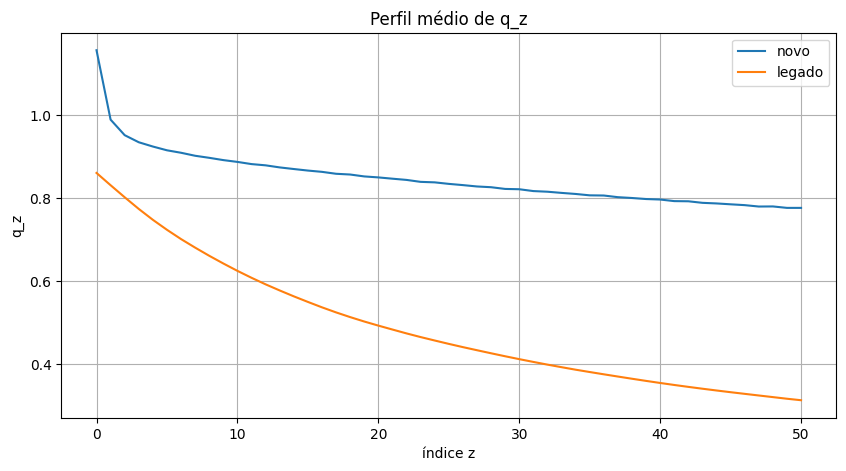

In [16]:
mean_qz_new = df_new[qz_cols].mean()
mean_qz_old = df_old[qz_cols].mean()

plt.figure(figsize=(10, 5))
plt.plot(mean_qz_new.values, label="novo")
plt.plot(mean_qz_old.values, label="legado")
plt.title("Perfil médio de q_z")
plt.xlabel("índice z")
plt.ylabel("q_z")
plt.legend()
plt.grid(True)
plt.show()

## Calculando o Qtot_final fora da rede:

In [17]:
def calc_qtot_final_from_row(row, qz_cols):
    qz = row[qz_cols].to_numpy(dtype=float)
    L = float(row["L"])
    D_col = float(row["D_col"])
    rho_B = float(row["rho_B"])

    z = np.linspace(0.0, L, len(qz))
    A = np.pi * (D_col ** 2) / 4.0
    integral = np.trapezoid(qz, z) if hasattr(np, "trapezoid") else np.trapz(qz, z)

    return A * rho_B * integral

In [19]:
kb = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="quantile")
qtot_bins = kb.fit_transform(df_new[["Qtot_final_calc"]]).astype(int).ravel()

pd.Series(qtot_bins).value_counts().sort_index()

c:\dev\projects\ProjetoNakajima\RN_Adsorcao_IC\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0    332481
1    334169
2    332351
Name: count, dtype: int64